In [5]:
# imports
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import pandas as pd
import seaborn as sns

import requests


In [2]:
# load cleaned price data from notebook 1
clean_prices_ffill = pd.read_csv("../data/sp500_close_prices_clean.csv", index_col=0, parse_dates=True)

# quick check
print(f"Loaded price matrix shape: {clean_prices_ffill.shape}")
print(f"Date range: {clean_prices_ffill.index[0]} to {clean_prices_ffill.index[-1]}")
clean_prices_ffill.head()


Loaded price matrix shape: (1217, 491)
Date range: 2021-02-10 00:00:00 to 2025-12-12 00:00:00


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-10,121.099747,131.992661,86.621986,211.660004,114.931175,33.176849,239.974411,492.670013,140.415771,47.708275,...,28.121014,113.178360,53.552238,42.490433,95.421776,257.489990,95.493797,149.828964,427.470001,153.799103
2021-02-11,122.919930,131.739166,86.372253,216.839996,116.353020,33.813953,241.870377,496.619995,145.520004,48.111237,...,27.998402,111.370468,52.941742,41.426510,93.346184,265.929993,96.555672,151.576370,470.079987,157.456924
2021-02-12,123.907478,131.973175,86.946678,212.679993,117.628082,33.424084,240.469421,498.839996,147.334366,48.812061,...,28.644201,114.548882,52.915955,41.991714,93.515999,272.750000,96.546494,150.800827,477.739990,159.630493
2021-02-16,123.878410,129.847885,86.746880,209.860001,117.435471,33.195866,240.077148,501.640015,147.068680,49.101143,...,28.521578,118.018852,52.030277,43.255119,93.383911,276.019989,96.665504,149.856995,486.010010,159.257080
2021-02-17,125.979347,127.556816,88.486809,201.960007,116.719933,33.614262,241.692917,491.230011,146.390503,48.987255,...,27.924820,118.747856,52.365639,43.928383,92.901375,270.940002,95.512100,148.184372,479.579987,161.727524


In [8]:
# daily returns
returns = clean_prices_ffill.pct_change().dropna()

# quick inspection
print(f"Returns matrix shape: {returns.shape}")
returns.head()

Returns matrix shape: (1216, 491)


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-11,0.015030,-0.001921,-0.002883,0.024473,0.012371,0.019203,0.007901,0.008017,0.036351,0.008446,...,-0.004360,-0.015974,-0.011400,-0.025039,-0.021752,0.032778,0.011120,0.011663,0.099679,0.023783
2021-02-12,0.008034,0.001776,0.006651,-0.019185,0.010959,-0.011530,-0.005792,0.004470,0.012468,0.014567,...,0.023066,0.028539,-0.000487,0.013644,0.001819,0.025646,-0.000095,-0.005117,0.016295,0.013804
2021-02-16,-0.000235,-0.016104,-0.002298,-0.013259,-0.001637,-0.006828,-0.001631,0.005613,-0.001803,0.005922,...,-0.004281,0.030292,-0.016737,0.030087,-0.001412,0.011989,0.001233,-0.006259,0.017311,-0.002339
2021-02-17,0.016960,-0.017644,0.020058,-0.037644,-0.006093,0.012604,0.006730,-0.020752,-0.004611,-0.002319,...,-0.020923,0.006177,0.006446,0.015565,-0.005167,-0.018404,-0.011932,-0.011161,-0.013230,0.015512
2021-02-18,-0.018752,-0.008637,-0.002164,-0.019410,-0.014382,-0.012164,-0.004444,-0.005822,-0.010391,-0.001788,...,-0.010246,-0.018826,0.022988,-0.015705,-0.014156,-0.000332,0.009872,-0.011162,-0.004024,-0.005625


In [4]:
# create weekly returns
prices_weekly = clean_prices_ffill.resample('W').last()
returns_weekly = prices_weekly.pct_change().dropna()
returns_weekly.to_csv("../data/sp500_returns_weekly.csv")
print(f"Weekly: {returns_weekly.shape}")


Weekly: (252, 491)


In [5]:
print("Missing values per stock (should be 0):")
print(returns.isna().sum().sort_values(ascending=False).head(10))


Missing values per stock (should be 0):
A       0
NXPI    0
NWS     0
NVR     0
NVDA    0
NUE     0
NTRS    0
NTAP    0
NSC     0
NRG     0
dtype: int64


In [6]:
# summary statistics per stock
returns_weekly.describe().T.head()  # transpose for readability


,count,mean,std,min,25%,50%,75%,max
A,252.0,0.001224,0.038757,-0.134409,-0.019673,-0.000178,0.023639,0.150210
AAPL,252.0,0.003662,0.037391,-0.135475,-0.019337,0.003323,0.024720,0.133264
ABBV,252.0,0.004270,0.032090,-0.172982,-0.010315,0.005495,0.021430,0.101678
ABNB,252.0,-0.000073,0.062298,-0.165958,-0.039528,0.003058,0.035111,0.208781
ABT,252.0,0.000712,0.030267,-0.076054,-0.016991,0.000710,0.019625,0.101780


In [7]:
# average return per day across all stocks
mean_daily_return = returns.mean(axis=1)

# daily volatility (std) across all stocks
daily_volatility = returns.std(axis=1)

# quick inspection
print(mean_daily_return.head())
print(daily_volatility.head())


Date
2021-02-11    0.001739
2021-02-12    0.004837
2021-02-16   -0.000264
2021-02-17   -0.000408
2021-02-18   -0.004965
dtype: float64
Date
2021-02-11    0.019994
2021-02-12    0.015422
2021-02-16    0.021304
2021-02-17    0.015653
2021-02-18    0.018180
dtype: float64


In [8]:
# average weekly return per week
mean_weekly_return = returns_weekly.mean(axis=1)

# weekly volatility across all stocks
weekly_volatility = returns_weekly.std(axis=1)

print(mean_weekly_return.head())
print(weekly_volatility.head())


Date
2021-02-21    0.000736
2021-02-28   -0.016314
2021-03-07    0.016026
2021-03-14    0.033989
2021-03-21   -0.004729
Freq: W-SUN, dtype: float64
Date
2021-02-21    0.037408
2021-02-28    0.046110
2021-03-07    0.052053
2021-03-14    0.037013
2021-03-21    0.037874
Freq: W-SUN, dtype: float64


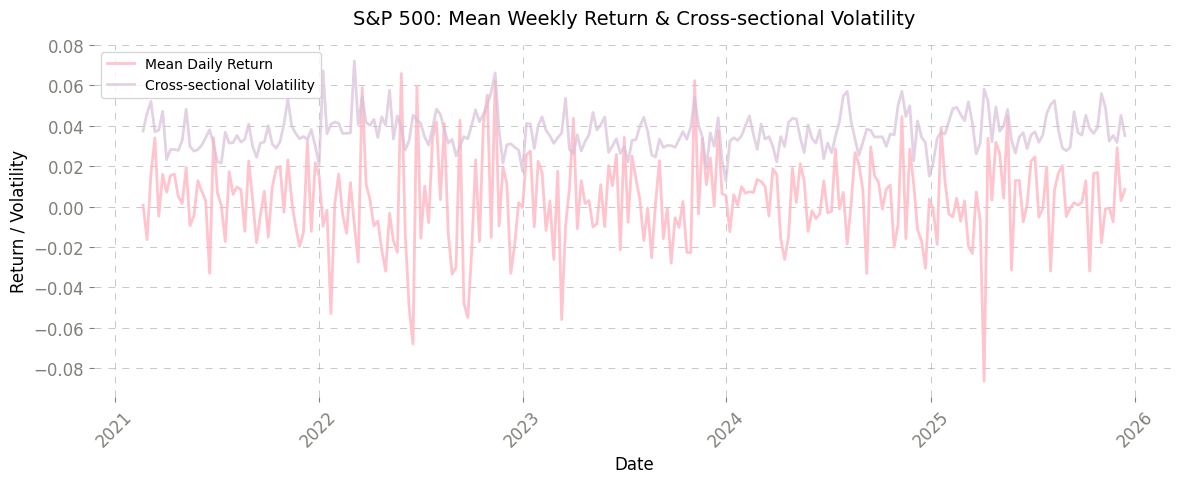

In [10]:
# visualisation mean weekly return & cross-sectional volatility

# style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12
fig, ax = plt.subplots(figsize=(12, 5))

# plot lines 
ax.plot(
    mean_weekly_return.index,
    mean_weekly_return,
    linewidth=2,
    alpha=0.8,
    color='#FFB6C1', 
    label="Mean Daily Return"
)

ax.plot(
    weekly_volatility.index,
    weekly_volatility,
    linewidth=2,
    alpha=0.7,
    color='#D8BFD8', 
    label="Cross-sectional Volatility"
)

# titles and labels
ax.set_title(
    "S&P 500: Mean Weekly Return & Cross-sectional Volatility",
    fontsize=14,
    pad=15
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Return / Volatility", fontsize=12)

# legend
ax.legend(fontsize=10)

# remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# grid
ax.grid(
    True,
    color="gray",
    linestyle=(0, (10, 10)),
    linewidth=0.5,
    alpha=0.6
)

# ticks
[t.set_color('#808079') for t in ax.yaxis.get_ticklabels()]
[t.set_color('#808079') for t in ax.xaxis.get_ticklabels()]
ax.tick_params(axis="x", colors="#808079")
ax.tick_params(axis="y", colors="#808079")

# rotate date labels
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../results/weekly_return.png", dpi=300, bbox_inches='tight')
plt.show()


In [11]:
# cross-sectional volatility stays stable (3-5%), indicating consistent stock dispersion
# mean returns oscillate around zero with high amplitude
# volatility spikes in 2022 and 2025 correlate with macro shocks
# mix of systematic (mean) and idiosyncratic (dispersion) risk visible


In [12]:
# calculate correlation matrix
corr_matrix = returns_weekly.corr()

print(f"Correlation matrix shape: {corr_matrix.shape}")
print( f"Average correlation: "
    f"{corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean():.3f}")


Correlation matrix shape: (491, 491)
Average correlation: 0.284


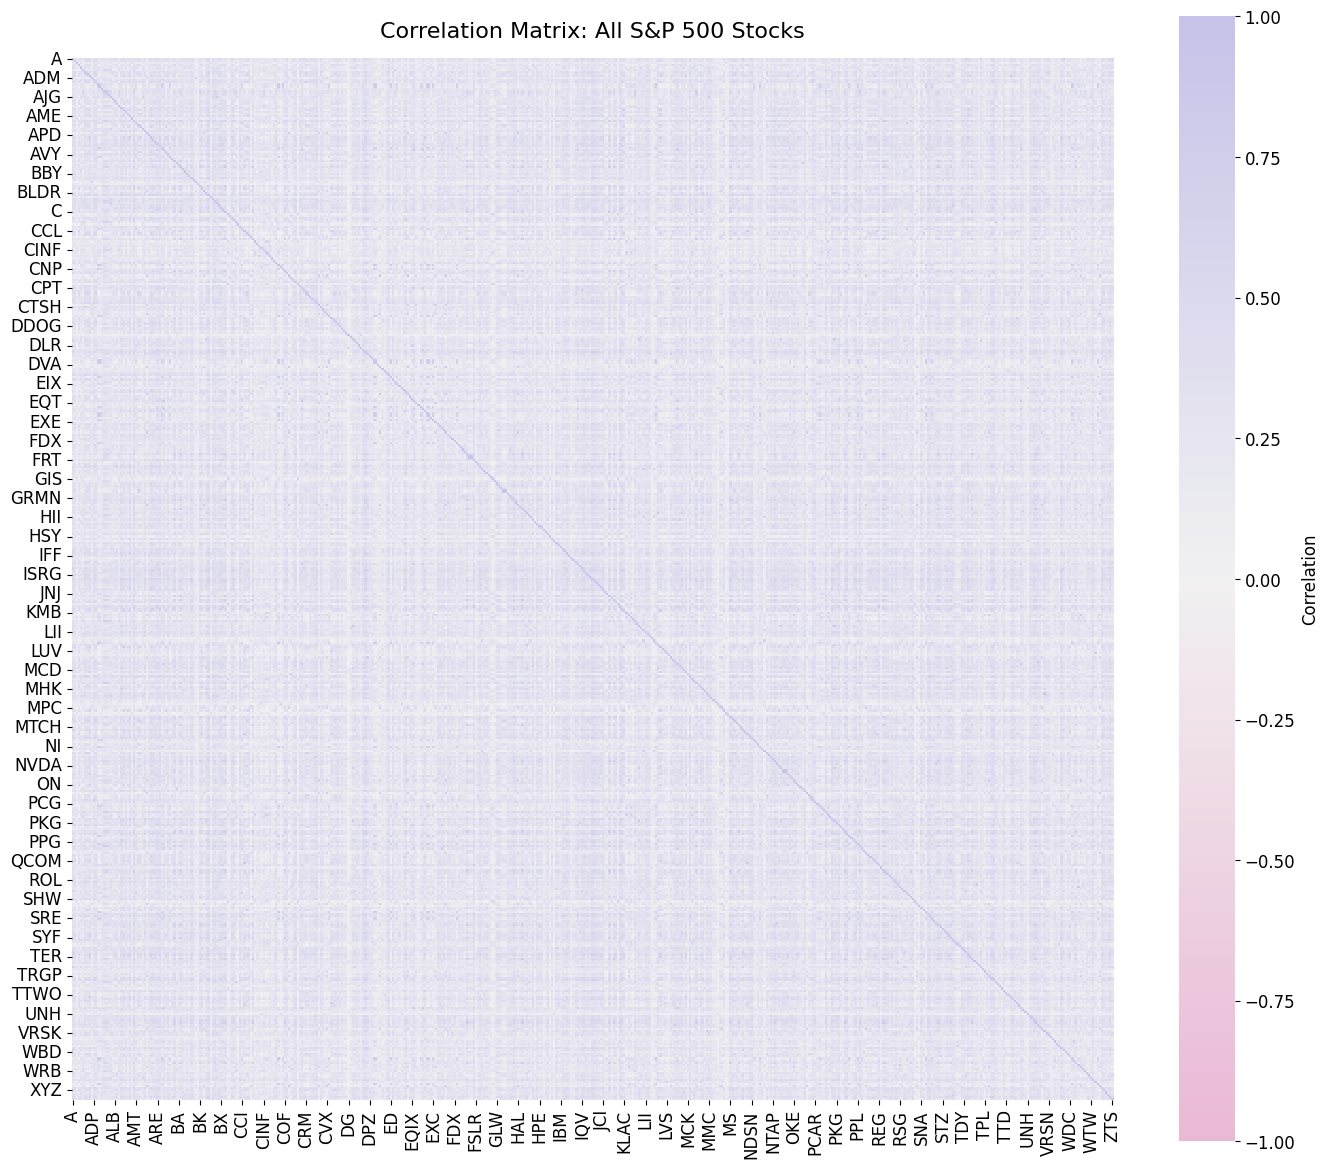

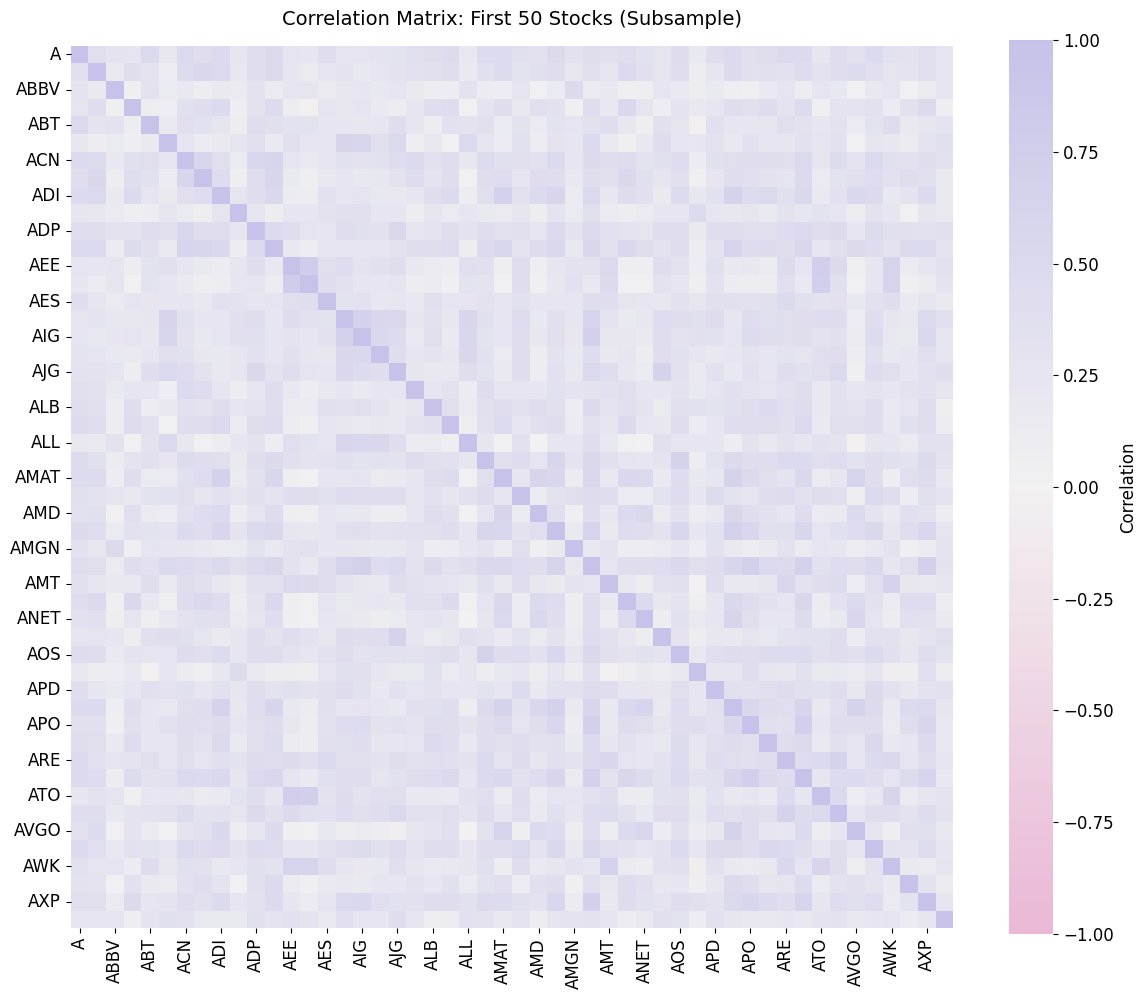

In [14]:
# visualisation correlation matrix

# style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

pastel_cmap = sns.diverging_palette(
    330, 
    270,   
    s=60,
    l=80,
    center="light",
    as_cmap=True
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    cmap=pastel_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={'label': 'Correlation'},
    linewidths=0.0
)

plt.title(
    "Correlation Matrix: All S&P 500 Stocks",
    fontsize=16,
    pad=15
)

plt.tight_layout()
plt.savefig("../results/corr_matrix_allstocks.png", dpi=300, bbox_inches='tight')
plt.show()


# visualise subsample first 50 stocks
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix.iloc[:50, :50],
    cmap=pastel_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={'label': 'Correlation'},
    linewidths=0.0
)

plt.title(
    "Correlation Matrix: First 50 Stocks (Subsample)",
    fontsize=14,
    pad=15
)

plt.tight_layout()
plt.savefig("../results/corr_matrix_50stocks.png", dpi=300, bbox_inches='tight')
plt.show()


In [15]:
# key insights:
# stocks within the same industry show higher correlations
# light purple baseline across the matrix confirms broad market co-movement
# darker patches identify sector-specific correlation groups

# diversification strategy: darker blocks reveal which stock combinations provide minimal risk reduction
# risk concentration: high-correlation clusters highlight areas of portfolio vulnerability during market stress
# low-correlation pairs signal potential hedging relationships

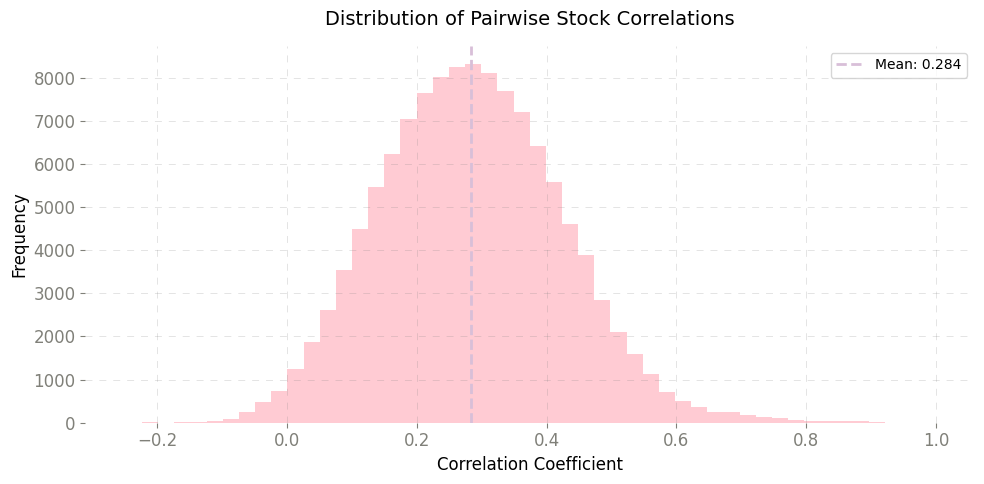


Correlation Statistics:
Mean correlation: 0.284
Median correlation: 0.280
Std correlation: 0.140
Pairs with correlation > 0.7: 643 (0.5%)


In [16]:
# visualisiation correlation distribution

# extract upper triangle (avoid diagonal and duplicates)
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
correlations = upper_triangle.stack()

# visualization
# style
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(10, 5))

# histogram with pastel colors
ax.hist(
    correlations,
    bins=50,
    edgecolor='none',
    alpha=0.7,
    color='#FFB6C1'  
)

# mean line
ax.axvline(
    correlations.mean(),
    color='#D8BFD8',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {correlations.mean():.3f}'
)

# titles and labels
ax.set_title(
    'Distribution of Pairwise Stock Correlations',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# legend
ax.legend(fontsize=10)

# grid
ax.grid(
    True,
    color="gray",
    linestyle=(0, (10, 10)),
    linewidth=0.5,
    alpha=0.3
)

# remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# ticks
[t.set_color('#808079') for t in ax.yaxis.get_ticklabels()]
[t.set_color('#808079') for t in ax.xaxis.get_ticklabels()]
ax.tick_params(axis="x", colors="#808079")
ax.tick_params(axis="y", colors="#808079")

plt.tight_layout()
plt.savefig("../results/distribution_of_corr.png", dpi=300, bbox_inches='tight')
plt.show()

# statistics
print(f"\nCorrelation Statistics:")
print(f"Mean correlation: {correlations.mean():.3f}")
print(f"Median correlation: {correlations.median():.3f}")
print(f"Std correlation: {correlations.std():.3f}")
print(
    f"Pairs with correlation > 0.7: {(correlations > 0.7).sum()} "
    f"({(correlations > 0.7).sum() / len(correlations) * 100:.1f}%)"
)


In [17]:
# correlation summary

# - mean correlation: 0.284 -> moderate positive correlation
# - on average, two random stocks move together 28.4%
# - median correlation: 0.28 -> close to the mean → distribution is fairly symmetric
# - confirms that most stock pairs have similar correlations
#
# - std correlation: 0.14 -> correlations not extremely dispersed (typical range ≈ 0.16 to 0.42), relatively stable
# - few strongly correlated pairs, majority moderately correlated
#
# - pairs with correlation > 0.7: 643 (0.5%)
# - very few pairs are highly correlated, most stocks move differently enough → supports diversification


In [18]:
# PCA justification

# - reduce dimensionality (491 stocks → few principal components) while preserving most variance
#
# - moderate average correlation (≈0.28) indicates some co-movement, but not too strong
#
# - PCA can identify common factors driving stock returns (market, sector trends)
#
# - no single pair dominates → PCA results will capture meaningful global patterns
#
# - correlation structure is stable enough for PCA to extract robust principal components
#
# - separating systematic risk factors from stock-specific noise
# 
# - computational efficiency, faster portfolio optimization and risk calculations on reduced feature space
#
# - subsequent PCs capture sector- or group-specific variations
